<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/4_April_Decision_Tree_Classifier_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Science Masters

In [1]:
# Import all required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## Q1. Decision Tree Classifier Algorithm — How It Works

### 📌 Definition
A **Decision Tree Classifier** is a supervised machine learning algorithm that learns a hierarchy of **if-else decision rules** from the training data. It recursively splits the dataset into subsets based on feature values, forming a tree structure where:
- **Root Node** — Represents the entire dataset; first best split happens here.
- **Internal/Decision Nodes** — Represent a test/condition on a feature.
- **Branches** — Represent the outcome (True/False or value ranges) of a test.
- **Leaf Nodes** — Represent the final predicted class label.

### 🔁 Step-by-Step Working
1. **Start at the Root:** The entire training dataset is placed at the root.
2. **Select Best Feature to Split:** An impurity measure (Gini Index or Entropy) is used to evaluate all features and pick the one that best separates the classes.
3. **Split the Data:** The dataset is divided into subsets based on the chosen feature's threshold/value.
4. **Recurse:** Steps 2–3 are repeated for each child node until a stopping criterion is met.
5. **Assign Leaf Labels:** Once splitting stops, each leaf node is assigned the majority class of samples it contains.
6. **Prediction:** A new sample traverses the tree from root to leaf following the decision rules, and the leaf's class label is the prediction.

### 🛑 Stopping Criteria
- All samples at a node belong to the same class (pure node).
- Maximum tree depth is reached.
- Minimum number of samples per node is reached.
- No further information gain is possible.

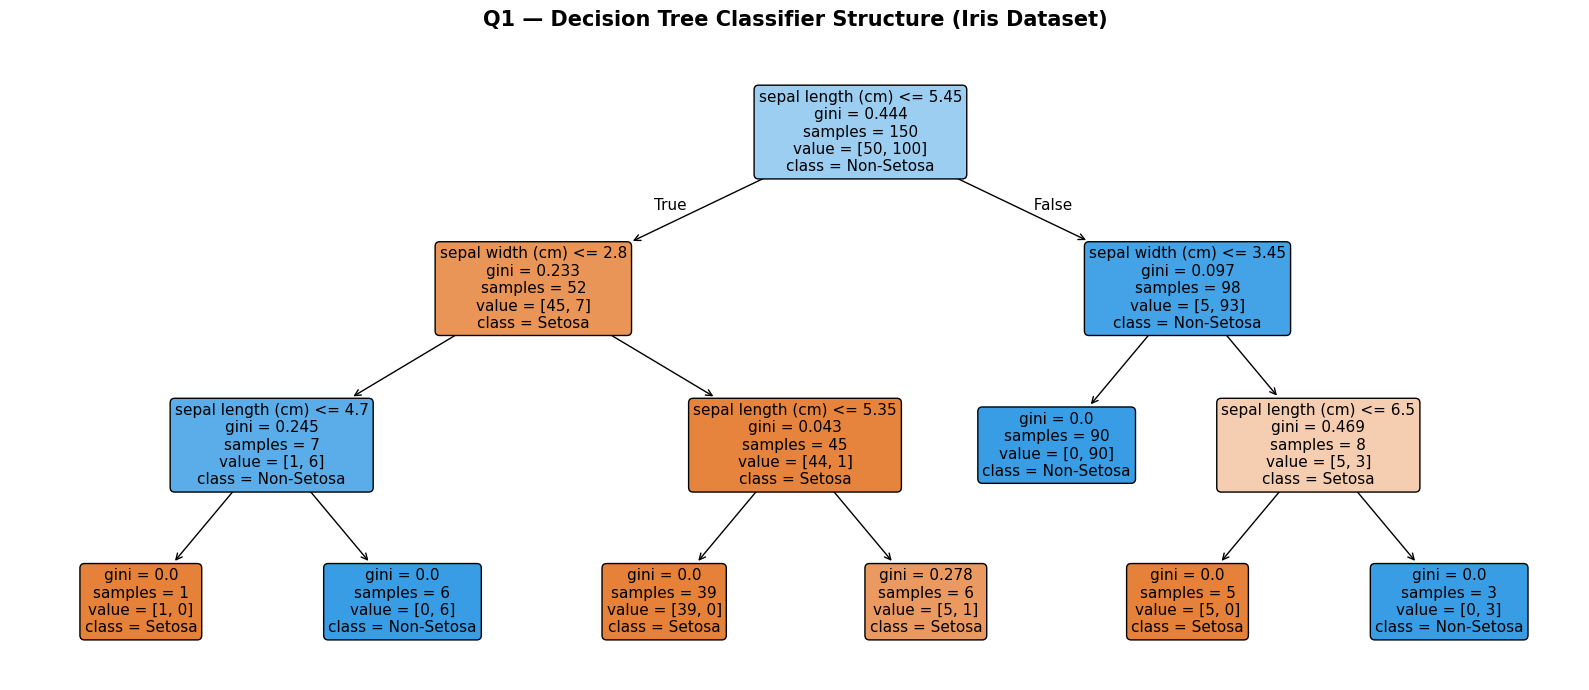


Text Representation of the Decision Tree:
|--- sepal length (cm) <= 5.45
|   |--- sepal width (cm) <= 2.80
|   |   |--- sepal length (cm) <= 4.70
|   |   |   |--- class: 0
|   |   |--- sepal length (cm) >  4.70
|   |   |   |--- class: 1
|   |--- sepal width (cm) >  2.80
|   |   |--- sepal length (cm) <= 5.35
|   |   |   |--- class: 0
|   |   |--- sepal length (cm) >  5.35
|   |   |   |--- class: 0
|--- sepal length (cm) >  5.45
|   |--- sepal width (cm) <= 3.45
|   |   |--- class: 1
|   |--- sepal width (cm) >  3.45
|   |   |--- sepal length (cm) <= 6.50
|   |   |   |--- class: 0
|   |   |--- sepal length (cm) >  6.50
|   |   |   |--- class: 1



In [2]:
#  Q1 Demo: Build and visualize a simple Decision Tree

# Create a simple toy dataset
from sklearn.datasets import load_iris
iris = load_iris()
X_iris = iris.data[:, :2]          # Use only 2 features for visualization
y_iris = (iris.target > 0).astype(int)  # Binary: 0 vs (1,2)

# Train a shallow decision tree
dt_iris = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_iris.fit(X_iris, y_iris)

# Plot the tree
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(
    dt_iris,
    feature_names=iris.feature_names[:2],
    class_names=["Setosa", "Non-Setosa"],
    filled=True,
    rounded=True,
    fontsize=11,
    ax=ax
)
ax.set_title("Q1 — Decision Tree Classifier Structure (Iris Dataset)",
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Print text representation
print("\nText Representation of the Decision Tree:")
print(export_text(dt_iris, feature_names=iris.feature_names[:2]))

---
## Q2. Mathematical Intuition Behind Decision Tree Classification

The key mathematical concept in decision trees is **how to choose the best split**. Two popular criteria are:

---

### 📐 1. Entropy & Information Gain

**Entropy** measures the impurity (disorder) of a node:

$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$

where $p_i$ is the proportion of class $i$ at node $S$, and $c$ is the number of classes.

- $H = 0$ → Perfect purity (all samples same class)
- $H = 1$ → Maximum impurity (equal split between classes)

**Information Gain** = Impurity reduction after a split:

$$IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} \cdot H(S_v)$$

The feature $A$ with the **highest Information Gain** is chosen as the split.

---

### 📐 2. Gini Impurity

$$Gini(S) = 1 - \sum_{i=1}^{c} p_i^2$$

- $Gini = 0$ → Perfect purity
- $Gini = 0.5$ → Maximum impurity (binary case)

**Gini Gain** for a split:

$$Gini\_Gain(S, A) = Gini(S) - \sum_{v} \frac{|S_v|}{|S|} \cdot Gini(S_v)$$

---

### 🔢 Step-by-Step Math Example (Binary, 10 samples: 6 Class A, 4 Class B)

**Before split:** $p_A = 0.6$, $p_B = 0.4$
$$H(S) = -(0.6 \log_2 0.6 + 0.4 \log_2 0.4) = 0.971$$

**After split on feature X:**
- Left child: 4 Class A, 1 Class B → $H_{left} = 0.722$
- Right child: 2 Class A, 3 Class B → $H_{right} = 0.971$

$$IG = 0.971 - \left(\frac{5}{10} \times 0.722 + \frac{5}{10} \times 0.971\right) = 0.124$$

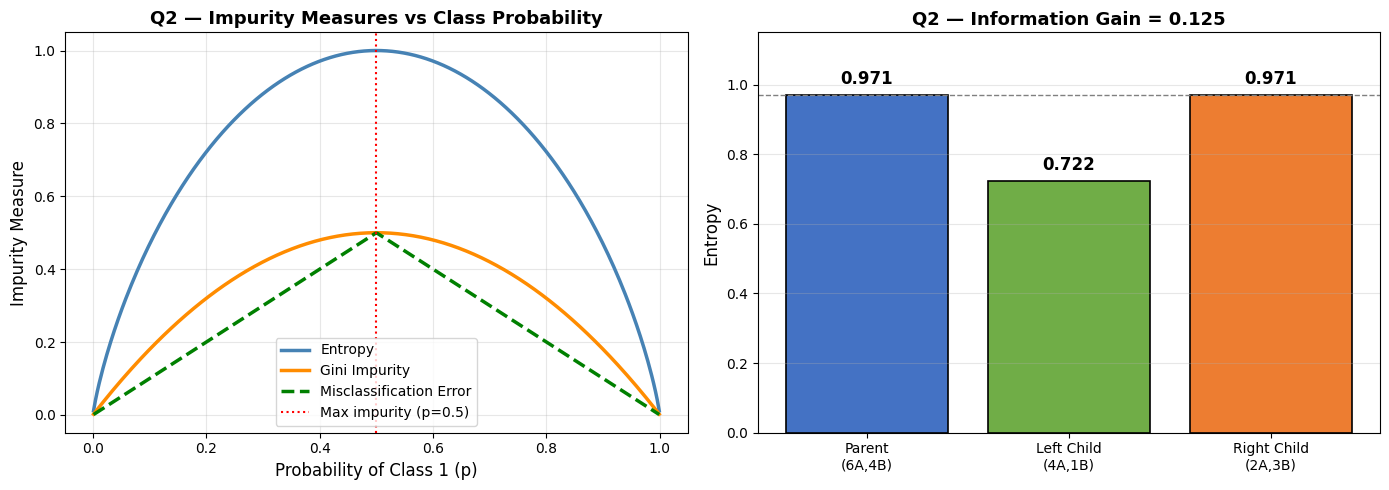

Parent Entropy     : 0.9710
Left Child Entropy : 0.7219  (4 A, 1 B)
Right Child Entropy: 0.9710  (2 A, 3 B)
Information Gain   : 0.1245


In [3]:
# Q2 Demo: Visualize Entropy and Gini vs class probability

p = np.linspace(0.001, 0.999, 300)

entropy   = -p * np.log2(p) - (1-p) * np.log2(1-p)
gini      = 1 - p**2 - (1-p)**2
mis_error = 1 - np.maximum(p, 1-p)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: All three curves
axes[0].plot(p, entropy,   label='Entropy',              color='steelblue',   lw=2.5)
axes[0].plot(p, gini,      label='Gini Impurity',        color='darkorange',  lw=2.5)
axes[0].plot(p, mis_error, label='Misclassification Error', color='green',    lw=2.5, linestyle='--')
axes[0].axvline(0.5, color='red', linestyle=':', lw=1.5, label='Max impurity (p=0.5)')
axes[0].set_xlabel('Probability of Class 1 (p)', fontsize=12)
axes[0].set_ylabel('Impurity Measure', fontsize=12)
axes[0].set_title('Q2 — Impurity Measures vs Class Probability', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Right: Manual Information Gain computation
# Parent: 6 A, 4 B
def entropy_calc(pos, neg):
    total = pos + neg
    if total == 0: return 0
    p1 = pos / total
    p2 = neg / total
    if p1 == 0 or p2 == 0: return 0
    return -(p1 * np.log2(p1) + p2 * np.log2(p2))

parent_H = entropy_calc(6, 4)
left_H   = entropy_calc(4, 1)
right_H  = entropy_calc(2, 3)
ig       = parent_H - (5/10 * left_H + 5/10 * right_H)

labels  = ['Parent\n(6A,4B)', 'Left Child\n(4A,1B)', 'Right Child\n(2A,3B)']
heights = [parent_H, left_H, right_H]
colors  = ['#4472C4', '#70AD47', '#ED7D31']

bars = axes[1].bar(labels, heights, color=colors, edgecolor='black', linewidth=1.2)
for bar, val in zip(bars, heights):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

axes[1].set_ylabel('Entropy', fontsize=12)
axes[1].set_title(f'Q2 — Information Gain = {ig:.3f}', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].axhline(parent_H, color='gray', linestyle='--', lw=1, label='Parent entropy')

plt.tight_layout()
plt.show()

print(f"Parent Entropy     : {parent_H:.4f}")
print(f"Left Child Entropy : {left_H:.4f}  (4 A, 1 B)")
print(f"Right Child Entropy: {right_H:.4f}  (2 A, 3 B)")
print(f"Information Gain   : {ig:.4f}")

---
## Q3. Decision Tree for Binary Classification — Step-by-Step

### 🎯 Problem Setup
**Goal:** Predict whether a tumour is **Malignant (1)** or **Benign (0)** using the Breast Cancer dataset.

### 🔢 Steps:
1. **Load and explore** the dataset.
2. **Split** into training and test sets (80/20).
3. **Train** a `DecisionTreeClassifier` with `criterion='gini'`.
4. **Predict** on the test set.
5. **Evaluate** using accuracy, confusion matrix, and classification report.
6. **Visualize** the decision tree.

In [4]:
# Q3: Binary Classification with Breast Cancer Dataset

# Step 1: Load dataset
data = load_breast_cancer()
X    = pd.DataFrame(data.data,   columns=data.feature_names)
y    = pd.Series(data.target,    name='target')

print("Dataset Shape:", X.shape)
print("Class Distribution:")
print(y.value_counts().rename({0: 'Malignant', 1: 'Benign'}))
print("\nFirst 5 rows of features:")
X.head()

Dataset Shape: (569, 30)
Class Distribution:
target
Benign       357
Malignant    212
Name: count, dtype: int64

First 5 rows of features:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Train size: 455 | Test size: 114

✅ Test Accuracy: 0.9211 (92.11%)

Classification Report:
              precision    recall  f1-score   support

   malignant       0.87      0.93      0.90        42
      benign       0.96      0.92      0.94        72

    accuracy                           0.92       114
   macro avg       0.91      0.92      0.92       114
weighted avg       0.92      0.92      0.92       114



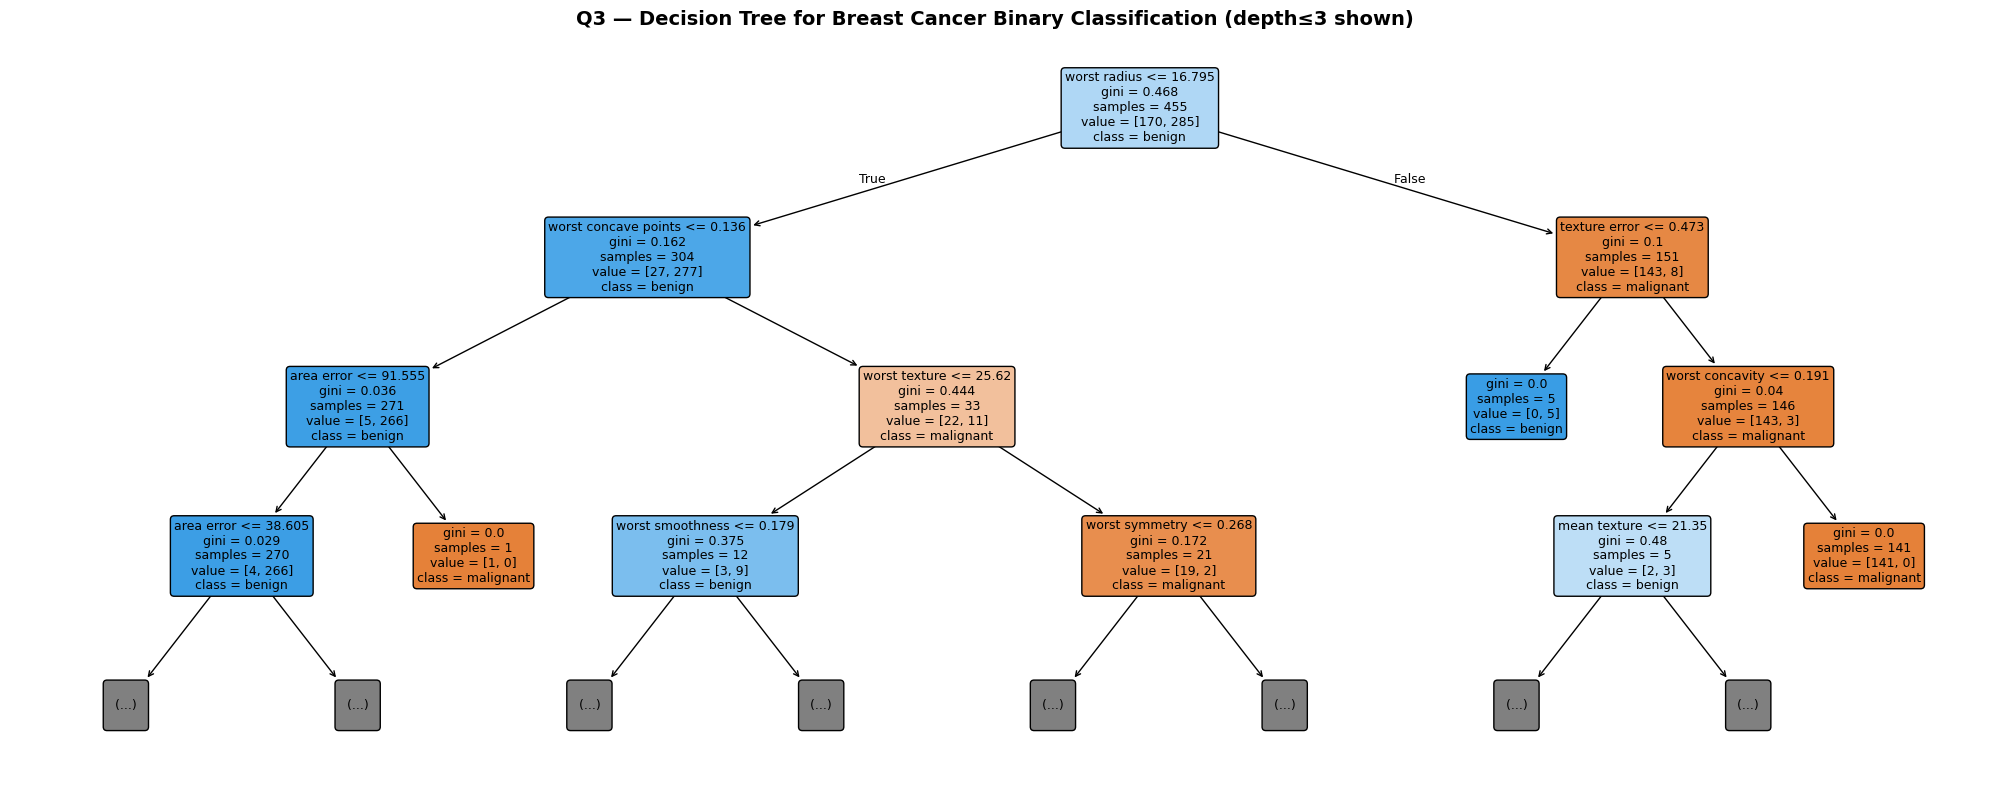

In [5]:
# Step 2: Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

# Step 3: Train Decision Tree
dt_bc = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_bc.fit(X_train, y_train)

# Step 4: Predict
y_pred = dt_bc.predict(X_test)

# Step 5: Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Step 6: Visualize (top 3 levels for readability)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_bc,
    max_depth=3,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)
ax.set_title("Q3 — Decision Tree for Breast Cancer Binary Classification (depth≤3 shown)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Q4. Geometric Intuition Behind Decision Tree Classification

### 🗺️ Geometric View
In feature space, a Decision Tree creates **axis-aligned rectangular decision boundaries** (hyperplanes perpendicular to the feature axes). Each split divides the feature space into two **rectangular regions**.

**Key Geometric Facts:**
- Each decision node creates a **vertical or horizontal line** in 2D space.
- The collection of all splits partitions the feature space into **non-overlapping rectangular regions**.
- Each region (leaf) is assigned one class label.
- Deeper trees → more rectangles → more complex boundaries → risk of overfitting.
- Unlike SVM (diagonal boundaries) or logistic regression (linear), DT boundaries are always **orthogonal** to feature axes.

### 🔮 Prediction:
Given a new point in feature space:
1. Determine which rectangular region it falls in.
2. Assign the class label of that region.

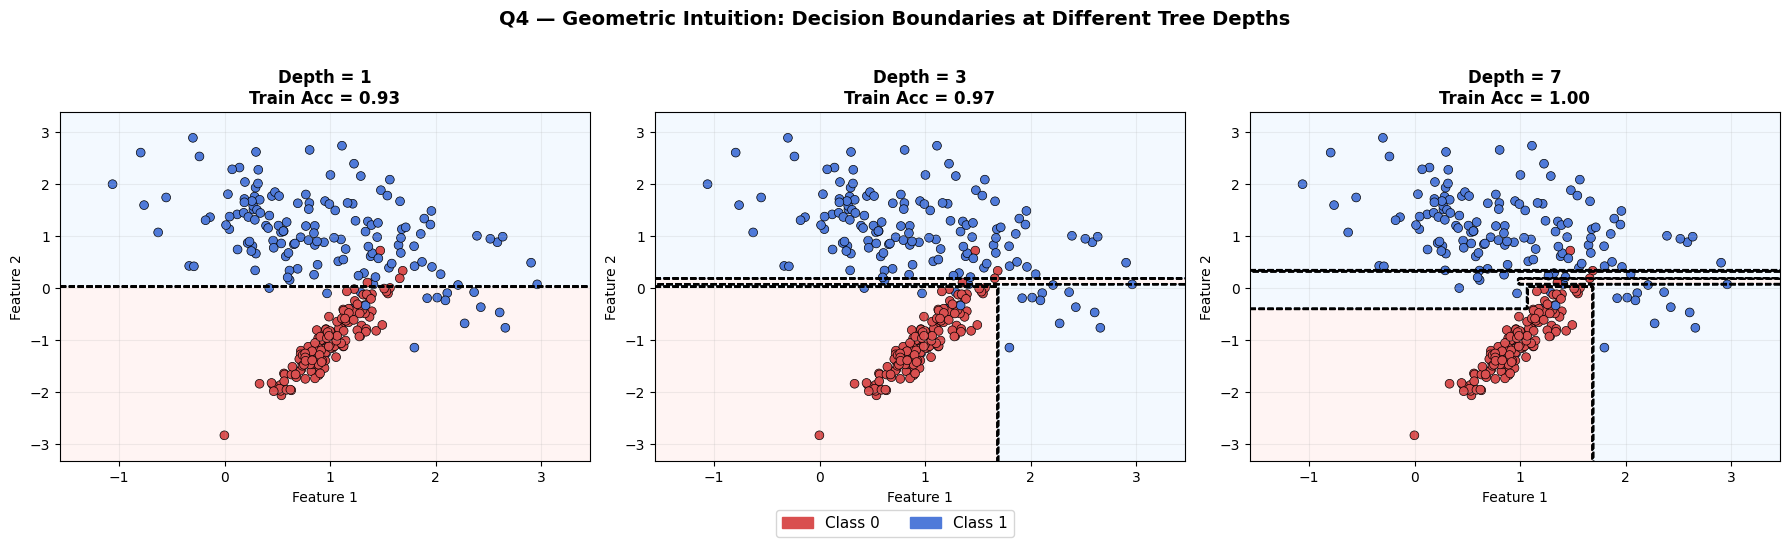

Observation: Deeper trees create more rectangular regions, fitting data better
but risking overfitting (depth=7 boundary is very jagged/complex).


In [6]:
#  Q4: Geometric Decision Boundary Visualization

# Use 2-feature synthetic dataset for clean geometric visualization
X_geo, y_geo = make_classification(
    n_samples=300, n_features=2, n_redundant=0,
    n_informative=2, n_clusters_per_class=1, random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
depths = [1, 3, 7]

# Mesh grid
x_min, x_max = X_geo[:, 0].min() - 0.5, X_geo[:, 0].max() + 0.5
y_min, y_max = X_geo[:, 1].min() - 0.5, X_geo[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
cmap_bg = ListedColormap(['#FFE4E1', '#E1F0FF'])
cmap_pt = ListedColormap(['#D94F4F', '#4F7AD9'])

for ax, depth in zip(axes, depths):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_geo, y_geo)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)
    ax.contour(xx, yy, Z, colors='black', linewidths=1.2, linestyles='--')
    scatter = ax.scatter(X_geo[:, 0], X_geo[:, 1], c=y_geo,
                         cmap=cmap_pt, edgecolors='k', s=40, linewidths=0.5)

    train_acc = clf.score(X_geo, y_geo)
    ax.set_title(f'Depth = {depth}\nTrain Acc = {train_acc:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.grid(alpha=0.2)

red_patch  = mpatches.Patch(color='#D94F4F', label='Class 0')
blue_patch = mpatches.Patch(color='#4F7AD9', label='Class 1')
fig.legend(handles=[red_patch, blue_patch], loc='lower center',
           ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.05))
fig.suptitle("Q4 — Geometric Intuition: Decision Boundaries at Different Tree Depths",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Observation: Deeper trees create more rectangular regions, fitting data better")
print("but risking overfitting (depth=7 boundary is very jagged/complex).")

---
## Q5. Confusion Matrix — Definition and Usage

### 📊 Definition
A **Confusion Matrix** is a table used to evaluate the performance of a classification model. It shows how many predictions were **correct** and how many were **misclassified**, broken down by class.

For a **Binary Classification** problem:

|                     | **Predicted: Positive** | **Predicted: Negative** |
|---------------------|------------------------|------------------------|
| **Actual: Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual: Negative** | False Positive (FP)    | True Negative (TN)     |

### 🔑 Key Terms
| Term | Meaning |
|------|--------|
| **TP** | Model predicted Positive AND it's actually Positive ✅ |
| **TN** | Model predicted Negative AND it's actually Negative ✅ |
| **FP** | Model predicted Positive BUT it's actually Negative ❌ (Type I Error) |
| **FN** | Model predicted Negative BUT it's actually Positive ❌ (Type II Error) |

### 📏 Metrics Derived from Confusion Matrix

$$\text{Accuracy}  = \frac{TP + TN}{TP + TN + FP + FN}$$

$$\text{Precision} = \frac{TP}{TP + FP}$$

$$\text{Recall}    = \frac{TP}{TP + FN}$$

$$\text{F1 Score}  = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### 💡 Why Confusion Matrix?
- Accuracy alone is misleading for **imbalanced datasets**.
- The confusion matrix reveals which **types of errors** the model makes.
- It guides selection of the right metric for the problem.

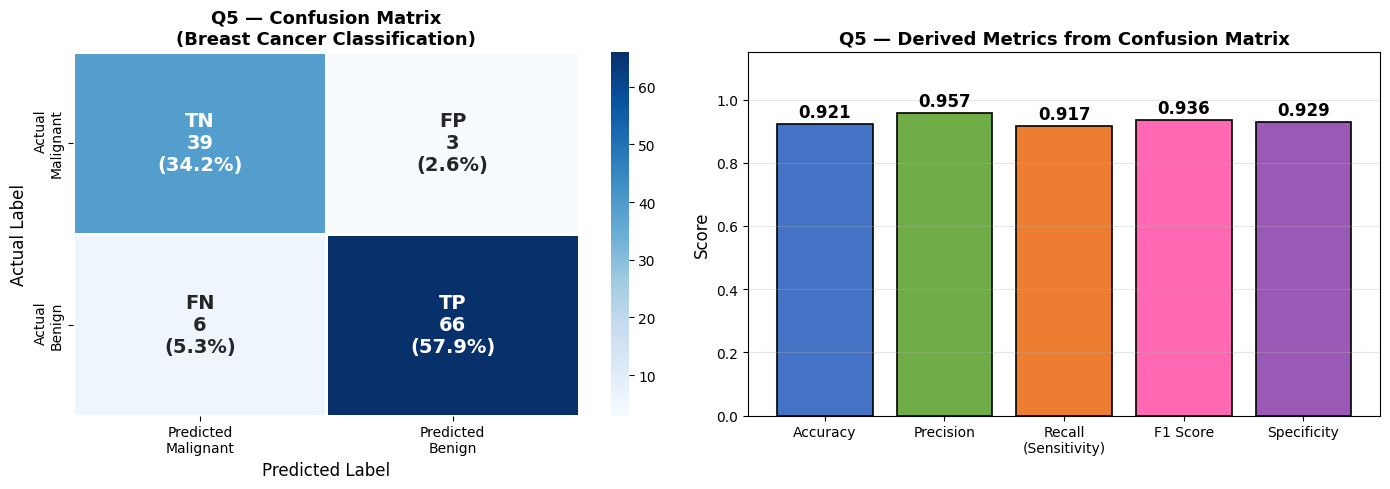

TP=66, TN=39, FP=3, FN=6
Accuracy    = 0.9211
Precision   = 0.9565
Recall      = 0.9167
F1 Score    = 0.9362
Specificity = 0.9286


In [7]:
# Q5: Visualize the Confusion Matrix from Breast Cancer Predictions

cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix Heatmap
group_labels = [f'TN\n{TN}', f'FP\n{FP}', f'FN\n{FN}', f'TP\n{TP}']
group_pct    = [f'({v/len(y_test)*100:.1f}%)' for v in [TN, FP, FN, TP]]
labels_arr   = np.array([f'{l}\n{p}' for l,p in zip(group_labels, group_pct)]).reshape(2,2)

sns.heatmap(cm, annot=labels_arr, fmt='', cmap='Blues',
            xticklabels=['Predicted\nMalignant', 'Predicted\nBenign'],
            yticklabels=['Actual\nMalignant', 'Actual\nBenign'],
            linewidths=2, linecolor='white', ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Q5 — Confusion Matrix\n(Breast Cancer Classification)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual Label', fontsize=12)
axes[0].set_xlabel('Predicted Label', fontsize=12)

# Plot 2: Metrics Bar Chart
total   = TP + TN + FP + FN
acc     = (TP + TN) / total
prec    = TP / (TP + FP) if (TP + FP) > 0 else 0
rec     = TP / (TP + FN) if (TP + FN) > 0 else 0
f1      = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
spec    = TN / (TN + FP) if (TN + FP) > 0 else 0

metric_names  = ['Accuracy', 'Precision', 'Recall\n(Sensitivity)', 'F1 Score', 'Specificity']
metric_values = [acc, prec, rec, f1, spec]
bar_colors    = ['#4472C4', '#70AD47', '#ED7D31', '#FF69B4', '#9B59B6']

bars = axes[1].bar(metric_names, metric_values, color=bar_colors, edgecolor='black', lw=1.2)
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Q5 — Derived Metrics from Confusion Matrix', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
print(f"Accuracy    = {acc:.4f}")
print(f"Precision   = {prec:.4f}")
print(f"Recall      = {rec:.4f}")
print(f"F1 Score    = {f1:.4f}")
print(f"Specificity = {spec:.4f}")

---
## Q6. Example Confusion Matrix — Precision, Recall, F1 Score Calculations

### 🧮 Manual Example

Suppose a spam email detector produces the following confusion matrix:

|                     | **Predicted: Spam** | **Predicted: Not Spam** |
|---------------------|--------------------|-----------------------|
| **Actual: Spam**     | TP = 90            | FN = 10               |
| **Actual: Not Spam** | FP = 20            | TN = 80               |

**Total = 200 samples**

### 📐 Calculations:

$$\text{Accuracy}  = \frac{90 + 80}{200} = \frac{170}{200} = 0.85$$

$$\text{Precision} = \frac{90}{90 + 20} = \frac{90}{110} \approx 0.818$$

$$\text{Recall}    = \frac{90}{90 + 10} = \frac{90}{100} = 0.900$$

$$\text{F1 Score}  = 2 \times \frac{0.818 \times 0.900}{0.818 + 0.900} \approx 0.857$$

### 💬 Interpretation:
- **Precision = 0.818:** When the model says "Spam", it's right 81.8% of the time.
- **Recall = 0.900:** Of all actual spam emails, 90% are correctly caught.
- **F1 = 0.857:** Balanced metric showing overall good performance.

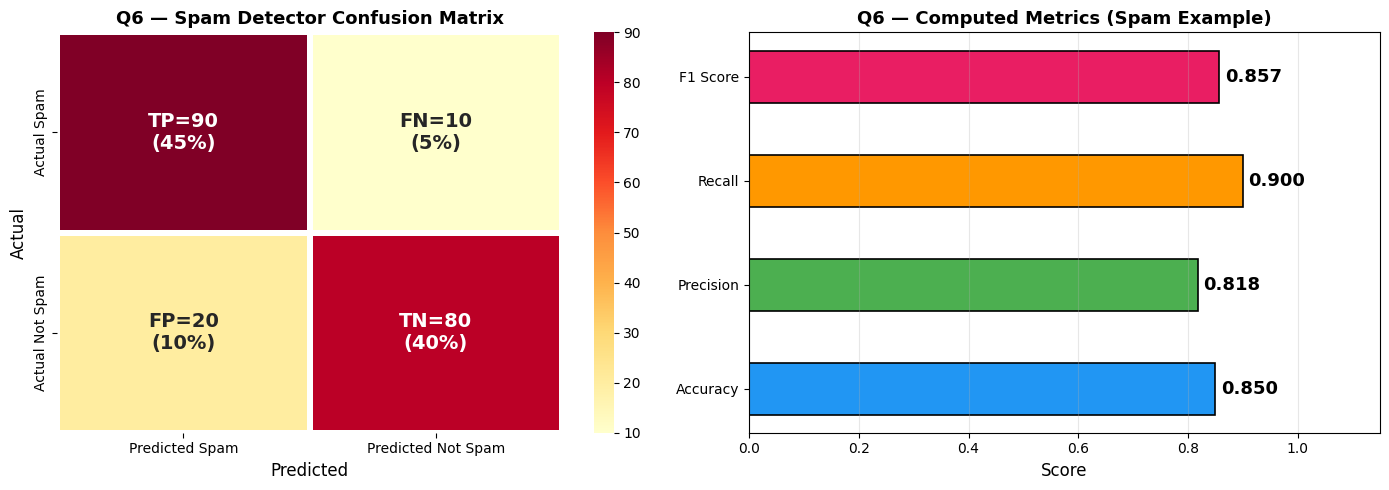

Manual Calculation — Spam Detector
  TP=90, FP=20, FN=10, TN=80  (Total=200)
  Accuracy  = (90+80)/200 = 0.850
  Precision = 90/(90+20) = 0.818
  Recall    = 90/(90+10) = 0.900
  F1 Score  = 2×0.818×0.900/(0.818+0.900) = 0.857


In [8]:
#  Q6: Manual Confusion Matrix Example — Spam Detector

# Define the confusion matrix
cm_manual = np.array([[90, 10],   # Actual Spam:     TP=90, FN=10
                       [20, 80]]) # Actual Not Spam:  FP=20, TN=80

TP_m, FN_m = 90, 10
FP_m, TN_m = 20, 80
total_m = TP_m + FN_m + FP_m + TN_m

accuracy_m  = (TP_m + TN_m) / total_m
precision_m = TP_m / (TP_m + FP_m)
recall_m    = TP_m / (TP_m + FN_m)
f1_m        = 2 * precision_m * recall_m / (precision_m + recall_m)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Heatmap of manual confusion matrix
labels_m = np.array([['TP=90\n(45%)', 'FN=10\n(5%)'],
                      ['FP=20\n(10%)', 'TN=80\n(40%)']])
sns.heatmap(cm_manual, annot=labels_m, fmt='', cmap='YlOrRd',
            xticklabels=['Predicted Spam', 'Predicted Not Spam'],
            yticklabels=['Actual Spam', 'Actual Not Spam'],
            linewidths=3, linecolor='white', ax=axes[0],
            annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title('Q6 — Spam Detector Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# Right: Metric display
metrics_m = {'Accuracy': accuracy_m, 'Precision': precision_m,
              'Recall': recall_m, 'F1 Score': f1_m}
colors_m  = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

bars = axes[1].barh(list(metrics_m.keys()), list(metrics_m.values()),
                    color=colors_m, edgecolor='black', linewidth=1.2, height=0.5)
for bar, val in zip(bars, metrics_m.values()):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, 1.15)
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_title('Q6 — Computed Metrics (Spam Example)', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("=" * 45)
print("Manual Calculation — Spam Detector")
print("=" * 45)
print(f"  TP={TP_m}, FP={FP_m}, FN={FN_m}, TN={TN_m}  (Total={total_m})")
print(f"  Accuracy  = ({TP_m}+{TN_m})/{total_m} = {accuracy_m:.3f}")
print(f"  Precision = {TP_m}/({TP_m}+{FP_m}) = {precision_m:.3f}")
print(f"  Recall    = {TP_m}/({TP_m}+{FN_m}) = {recall_m:.3f}")
print(f"  F1 Score  = 2×{precision_m:.3f}×{recall_m:.3f}/({precision_m:.3f}+{recall_m:.3f}) = {f1_m:.3f}")

---
## Q7. Choosing the Right Evaluation Metric — Importance & How-To

### ⚠️ Why Metric Choice Matters
Different real-world problems have **different costs for different types of errors**. Choosing the wrong metric can lead to:
- Deploying a model that looks good on paper but fails in practice.
- Ignoring minority class performance in imbalanced datasets.
- Missing critical errors (e.g., failing to detect a disease).

### 📋 Decision Guide for Metric Selection

| Situation | Best Metric | Reason |
|-----------|------------|--------|
| Balanced classes, overall performance | **Accuracy** | Equal cost for all errors |
| FP is very costly (spam, fraud alerts) | **Precision** | Minimize false alarms |
| FN is very costly (disease detection) | **Recall** | Minimize missed positives |
| Both FP and FN matter equally | **F1 Score** | Harmonic mean balances both |
| Imbalanced dataset | **F1 / ROC-AUC / PR-AUC** | Accuracy misleads here |
| Ranking/threshold flexibility | **ROC-AUC** | Threshold-independent |

### 🔧 How to Choose:
1. **Define the cost** of FP vs FN for your domain.
2. **Check class balance** — if severe imbalance, avoid raw accuracy.
3. **Consult domain experts** (doctors, fraud analysts, etc.).
4. **Use multiple metrics** and pick primary based on business impact.
5. **Examine confusion matrix** for full error breakdown.

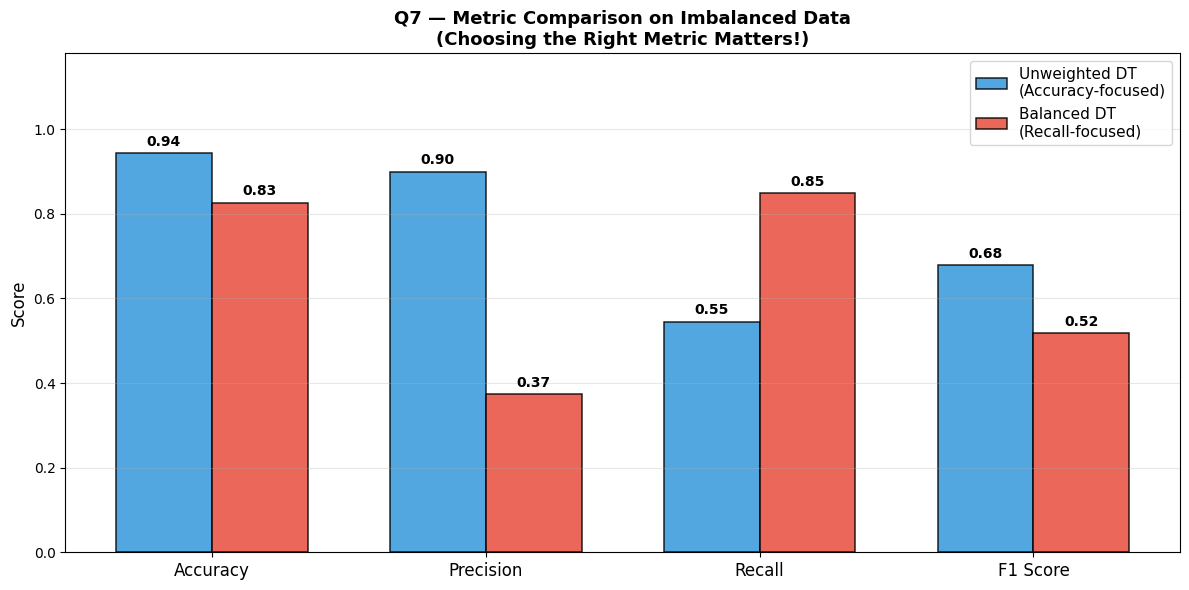

Insight: High accuracy doesn't mean a good model on imbalanced data!
The balanced model has lower accuracy but much better Recall & F1.


In [9]:
# Q7: Metric Comparison on Imbalanced Dataset

# Create imbalanced dataset (90% class 0, 10% class 1)
X_imb, y_imb = make_classification(
    n_samples=1000, n_features=10, n_classes=2,
    weights=[0.90, 0.10], flip_y=0, random_state=42
)
X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

# Train two models: accuracy-optimized vs recall-optimized
dt_acc  = DecisionTreeClassifier(max_depth=3, class_weight=None,        random_state=42)
dt_rec  = DecisionTreeClassifier(max_depth=3, class_weight='balanced',  random_state=42)

dt_acc.fit(X_tr, y_tr);  pred_acc = dt_acc.predict(X_te)
dt_rec.fit(X_tr, y_tr);  pred_rec = dt_rec.predict(X_te)

# Compare metrics
models  = ['Unweighted DT\n(Accuracy-focused)', 'Balanced DT\n(Recall-focused)']
preds   = [pred_acc, pred_rec]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

results = []
for model_name, pred in zip(models, preds):
    results.append([
        accuracy_score(y_te, pred),
        precision_score(y_te, pred, zero_division=0),
        recall_score(y_te, pred, zero_division=0),
        f1_score(y_te, pred, zero_division=0)
    ])

x    = np.arange(len(metrics))
w    = 0.35
cols = ['#3498DB', '#E74C3C']

fig, ax = plt.subplots(figsize=(12, 6))
for i, (name, res, col) in enumerate(zip(models, results, cols)):
    bars = ax.bar(x + i*w - w/2, res, w, label=name, color=col,
                  edgecolor='black', linewidth=1.1, alpha=0.85)
    for bar, val in zip(bars, res):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.18)
ax.set_title('Q7 — Metric Comparison on Imbalanced Data\n(Choosing the Right Metric Matters!)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("Insight: High accuracy doesn't mean a good model on imbalanced data!")
print("The balanced model has lower accuracy but much better Recall & F1.")

---
## Q8. Example Where PRECISION Is the Most Important Metric

### 🎯 Problem: Email Spam Detection

**Scenario:** An email provider builds a spam classifier. Incorrectly labeling a legitimate email (ham) as spam (False Positive) means the user **misses an important email** — possibly a job offer, medical report, or banking alert.

### ❓ Why Precision?

$$\text{Precision} = \frac{TP}{TP + FP}$$

- **FP (False Positive) Cost is HIGH** → A real email goes to spam folder → user misses it → trust in system is destroyed.
- **FN (False Negative) Cost is LOW** → A spam email reaches the inbox → minor inconvenience, user deletes it.

**We want to minimize FP → Maximize Precision.**

### Other Precision-Priority Examples:
- **Drug recommendation systems** — recommending a wrong drug is catastrophic.
- **Legal document fraud detection** — falsely flagging legitimate documents as fraud has severe consequences.
- **Product recommendation** — recommending an irrelevant product wastes user experience.

### 🔑 Rule of Thumb:
> **"When a False Positive is more costly than a False Negative → Use Precision"**

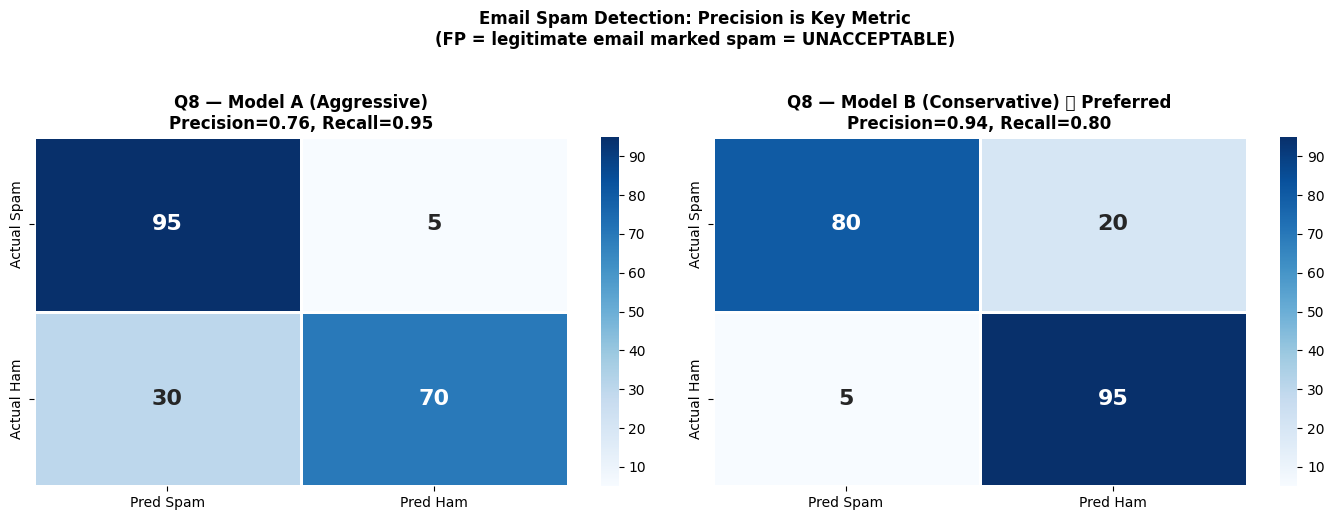

Model A: Catches more spam (high recall) but marks 30 real emails as spam (low precision) ❌
Model B: Lets 20 spam through (lower recall) but marks only 5 real emails as spam ✅

For spam detection, Model B is preferred because Precision (0.94) is higher.
Missing spam is acceptable; mislabeling real emails is NOT.


In [10]:
#  Q8: Precision-Focused Example — Spam Detection

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Illustrative Confusion Matrices for two classifiers ──
# Model A: High Recall, Low Precision (aggressive spam filter)
cm_A = np.array([[95, 5], [30, 70]])   # TP=95, FN=5, FP=30, TN=70
# Model B: High Precision, OK Recall (conservative spam filter)
cm_B = np.array([[80, 20], [5, 95]])   # TP=80, FN=20, FP=5, TN=95

prec_A = 95/(95+30);  rec_A = 95/(95+5)
prec_B = 80/(80+5);   rec_B = 80/(80+20)

for ax, cm, title, prec, rec in [
    (axes[0], cm_A, f'Model A (Aggressive)\nPrecision={prec_A:.2f}, Recall={rec_A:.2f}', prec_A, rec_A),
    (axes[1], cm_B, f'Model B (Conservative) ✅ Preferred\nPrecision={prec_B:.2f}, Recall={rec_B:.2f}', prec_B, rec_B)
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Spam', 'Pred Ham'],
                yticklabels=['Actual Spam', 'Actual Ham'],
                linewidths=2, linecolor='white', ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'Q8 — {title}', fontsize=12, fontweight='bold')

plt.suptitle('Email Spam Detection: Precision is Key Metric\n(FP = legitimate email marked spam = UNACCEPTABLE)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Model A: Catches more spam (high recall) but marks 30 real emails as spam (low precision) ❌")
print("Model B: Lets 20 spam through (lower recall) but marks only 5 real emails as spam ✅")
print(f"\nFor spam detection, Model B is preferred because Precision ({prec_B:.2f}) is higher.")
print("Missing spam is acceptable; mislabeling real emails is NOT.")

---
## Q9. Example Where RECALL Is the Most Important Metric

### 🎯 Problem: Cancer/Disease Detection

**Scenario:** A machine learning model is built to screen patients for cancer. Missing a real cancer patient (False Negative) means **the disease goes undetected and untreated** — potentially fatal. Falsely flagging a healthy person (False Positive) leads to further tests, which is costly but not dangerous.

### ❓ Why Recall?

$$\text{Recall} = \frac{TP}{TP + FN}$$

- **FN (False Negative) Cost is EXTREMELY HIGH** → A cancer patient is told they're healthy → they don't get treatment → possibly fatal.
- **FP (False Positive) Cost is LOW** → A healthy person is told to do more tests → inconvenience, cost, but manageable.

**We want to minimize FN → Maximize Recall (Sensitivity).**

### Other Recall-Priority Examples:
- **COVID-19 / Infectious Disease Screening** — Missing infected person spreads disease.
- **Credit card fraud detection** — Missing a fraudulent transaction costs money.
- **Structural fault detection** (bridges, aircraft) — Missing a defect causes catastrophe.
- **Wildfire/disaster early warning** — Missing the alert → lives lost.

### 🔑 Rule of Thumb:
> **"When a False Negative is more costly than a False Positive → Use Recall"**

---

### 📌 Summary Table

| Metric | Formula | Use When |
|--------|---------|----------|
| **Precision** | TP / (TP + FP) | FP is costly (spam, fraud alerts, drug recommendations) |
| **Recall** | TP / (TP + FN) | FN is costly (disease detection, fraud transactions) |
| **F1 Score** | Harmonic mean of P & R | Both FP and FN are equally important |
| **Accuracy** | (TP+TN) / Total | Balanced classes, overall correctness matters |

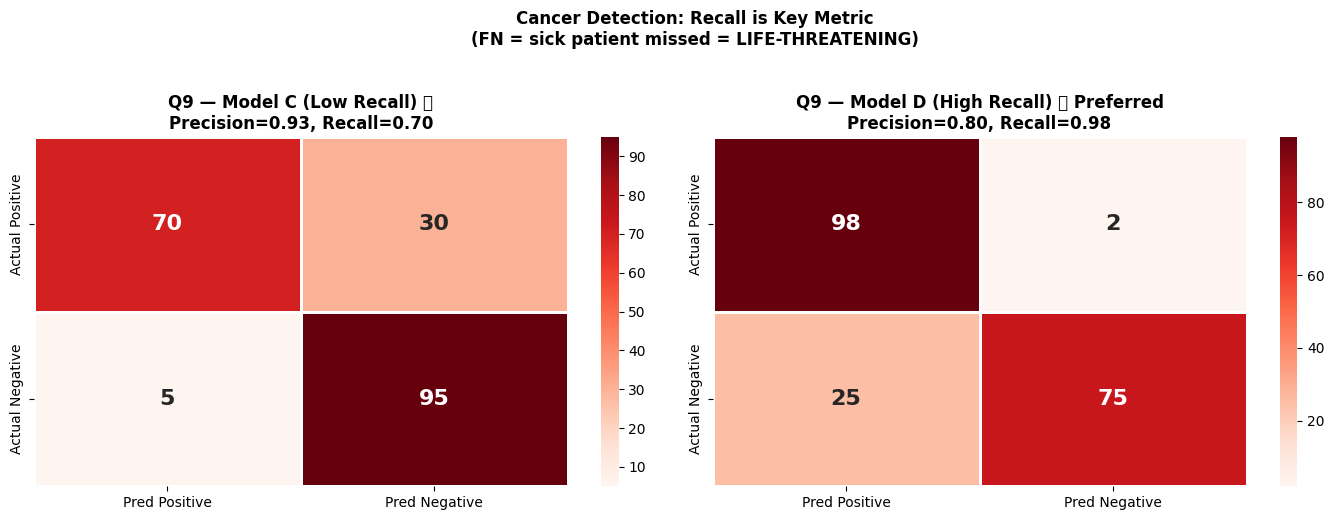

Model C: High precision but misses 30 cancer patients (FN=30) — UNACCEPTABLE ❌
Model D: 25 false alarms but catches 98/100 cancer patients (FN=2) — PREFERRED ✅

For disease detection, Model D is preferred because Recall (0.98) is higher.
False alarms mean extra tests; missed diagnoses can be fatal.


In [11]:
# Q9: Recall-Focused Example — Disease Detection

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Model C: High Precision, Low Recall (conservative) — BAD for disease detection
cm_C = np.array([[70, 30], [5, 95]])   # TP=70, FN=30, FP=5, TN=95
# Model D: High Recall, OK Precision (sensitive) — GOOD for disease detection
cm_D = np.array([[98, 2], [25, 75]])   # TP=98, FN=2, FP=25, TN=75

prec_C = 70/(70+5);   rec_C = 70/(70+30)
prec_D = 98/(98+25);  rec_D = 98/(98+2)

for ax, cm, title in [
    (axes[0], cm_C, f'Model C (Low Recall) ❌\nPrecision={prec_C:.2f}, Recall={rec_C:.2f}'),
    (axes[1], cm_D, f'Model D (High Recall) ✅ Preferred\nPrecision={prec_D:.2f}, Recall={rec_D:.2f}')
]:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=['Pred Positive', 'Pred Negative'],
                yticklabels=['Actual Positive', 'Actual Negative'],
                linewidths=2, linecolor='white', ax=ax,
                annot_kws={'size': 16, 'weight': 'bold'})
    ax.set_title(f'Q9 — {title}', fontsize=12, fontweight='bold')

plt.suptitle('Cancer Detection: Recall is Key Metric\n(FN = sick patient missed = LIFE-THREATENING)',
             fontsize=12, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print("Model C: High precision but misses 30 cancer patients (FN=30) — UNACCEPTABLE ❌")
print("Model D: 25 false alarms but catches 98/100 cancer patients (FN=2) — PREFERRED ✅")
print(f"\nFor disease detection, Model D is preferred because Recall ({rec_D:.2f}) is higher.")
print("False alarms mean extra tests; missed diagnoses can be fatal.")